# Connessione al db

In [6]:
import pandas as pd
import numpy as np
import sys
sys.path.append('..')
from script.connessioni import get_mysql_connection

import matplotlib.pyplot as plt
import os

# Configurazione pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

In [7]:
conn = get_mysql_connection()

# Carica tutti i dati da raw_data in un DataFrame
query = "SELECT * FROM clean_data"
df = pd.read_sql(query, conn)

conn.close()

print(f"Dataset caricato: {df.shape[0]} righe, {df.shape[1]} colonne")
df.head()

Dataset caricato: 144 righe, 37 colonne


C:\Users\Utente\AppData\Local\Temp\ipykernel_23956\3523368477.py:5: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,id,email,contesto,età,genere,area_geo,anni_esperienza,Item_1,Item_2,Item_3,Item_4,Item_5,Item_6,Item_7,Item_8,Item_9,Item_10,Item_11,Item_12,Item_13,Item_14,Item_15,Item_16,Item_17,Item_18,Item_19,Item_20,Item_21,Item_22,Item_23,Item_24,Item_25,Item_26,Item_27,Item_28,Item_29,Item_30
0,1,None,Entrambi,24,Femmina,Nord Italia,5.0,4,5,4,4,4,4.0,4.0,5.0,5.0,5.0,5.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,5.0,5,5,1,1,2,2,4,5,5,Durante gli esami e se devo interagire con gli...
1,2,None,Studio,26,Femmina,Nord Italia,7.0,4,5,3,4,3,4.0,3.0,2.0,3.0,4.0,4.0,4.0,4.0,4.0,3.0,NaN,NaN,NaN,NaN,NaN,4,1,3,3,5,2,2,2,4,Durante gli esami
2,3,None,Lavoro,26,Maschio,Nord Italia,5.0,3,4,3,4,4,4.0,5.0,3.0,2.0,1.0,NaN,NaN,NaN,NaN,NaN,4.0,2.0,4.0,5.0,5.0,3,5,1,1,4,2,5,4,5,Interazione con persone (clienti)
3,4,None,Entrambi,26,Femmina,Nord Italia,5.0,2,4,3,5,5,3.0,3.0,3.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,4.0,5.0,3.0,5.0,3.0,2,5,3,3,2,3,2,1,3,L’esame
4,5,None,Studio,22,Femmina,Nord Italia,2.0,3,2,3,4,4,3.0,2.0,2.0,3.0,1.0,4.0,3.0,3.0,3.0,2.0,NaN,NaN,NaN,NaN,NaN,2,2,3,2,4,3,3,2,4,"Durante il tirocinio, quando devo mettere effe..."


# Calcolo degli indici

In [8]:
df["ansia_prestazione"] = df[["Item_1", "Item_2", "Item_3", "Item_4", "Item_6", "Item_11", "Item_20", "Item_21"]].mean(axis=1)
df["ansia_accademica"] = df[["Item_7", "Item_8", "Item_9", "Item_10"]].mean(axis=1)
df["ansia_lavorativa"] = df[["Item_12", "Item_13", "Item_14", "Item_15"]].mean(axis=1)
df["perfezionismo"] = df[["Item_16", "Item_17", "Item_18", "Item_19"]].mean(axis=1)
df["impatto_ansia"] = df[["Item_5", "Item_22", "Item_27", "Item_28", "Item_29"]].mean(axis=1)
df["coping"] = df[["Item_23", "Item_24", "Item_25", "Item_26"]].mean(axis=1)

In [9]:
# ansia totale
df['ansia'] = df[["ansia_prestazione", "ansia_accademica", "ansia_lavorativa"]].mean(axis=1)

In [10]:
# fragilità/esposizione allo stress
df["vulnerabilita"] = (df["perfezionismo"] + df["ansia"]) / 2

# capacità di fronteggiare l'ansia
df["resilienza"] = (df["coping"] - df["ansia"])

# gap percezione-prestazione (quanto l’ansia distorce la performance )
df["gap"] = (df["Item_8"] - df["coping"])

# evitamento delle situazioni che mettono ansia
df["evitamento"] = df[["Item_10", "Item_15", "Item_27", "Item_28"]].mean(axis=1)

# intensità dei sintomi
df["intensita_sintomatica"] = df [["Item_20", "Item_21", "Item_22"]].mean(axis=1)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 49 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     144 non-null    int64  
 1   email                  12 non-null     object 
 2   contesto               144 non-null    object 
 3   età                    144 non-null    int64  
 4   genere                 144 non-null    object 
 5   area_geo               144 non-null    object 
 6   anni_esperienza        144 non-null    float64
 7   Item_1                 144 non-null    int64  
 8   Item_2                 144 non-null    int64  
 9   Item_3                 144 non-null    int64  
 10  Item_4                 144 non-null    int64  
 11  Item_5                 144 non-null    int64  
 12  Item_6                 141 non-null    float64
 13  Item_7                 141 non-null    float64
 14  Item_8                 141 non-null    float64
 15  Item_9

# Distribuzioni

(array([0.5, 1. , 1.5, 2. , 2.5, 3. , 3.5, 4. , 4.5, 5. , 5.5]),
 [Text(0.5, 0, '0.5'),
  Text(1.0, 0, '1.0'),
  Text(1.5, 0, '1.5'),
  Text(2.0, 0, '2.0'),
  Text(2.5, 0, '2.5'),
  Text(3.0, 0, '3.0'),
  Text(3.5, 0, '3.5'),
  Text(4.0, 0, '4.0'),
  Text(4.5, 0, '4.5'),
  Text(5.0, 0, '5.0'),
  Text(5.5, 0, '5.5')])

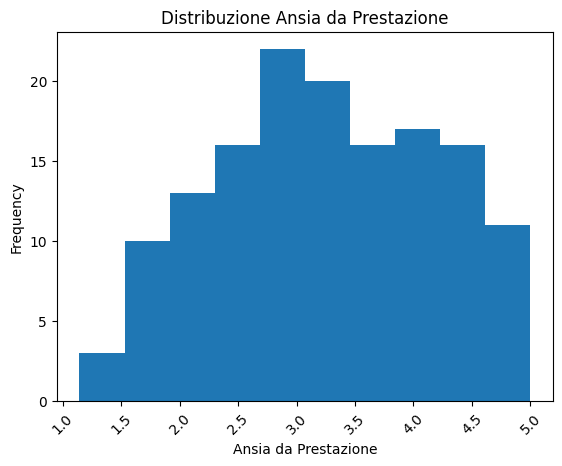

In [12]:
import matplotlib.pyplot as plt

df["ansia_prestazione"].plot(kind = 'hist')
plt.xlabel('Ansia da Prestazione')
plt.title('Distribuzione Ansia da Prestazione')
plt.xticks(rotation=45)

# Correlazioni

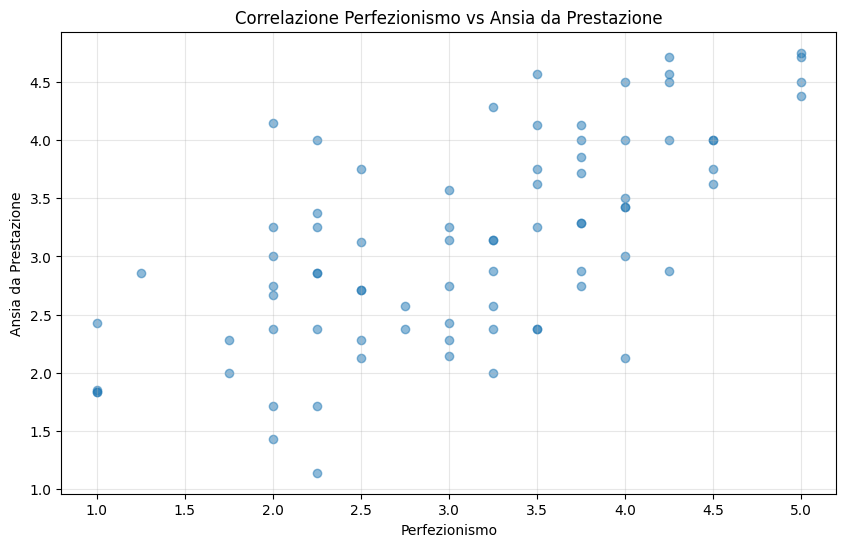

In [13]:
plt.figure(figsize=(10, 6))
plt.scatter(df["perfezionismo"], df["ansia_prestazione"], alpha=0.5)
plt.xlabel('Perfezionismo')
plt.ylabel('Ansia da Prestazione')
plt.title(f'Correlazione Perfezionismo vs Ansia da Prestazione')
plt.grid(True, alpha=0.3)

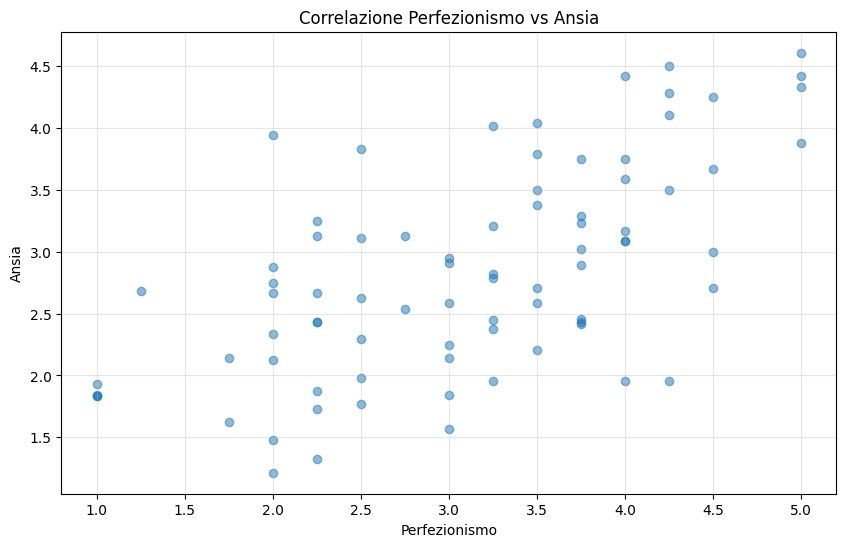

In [14]:
plt.figure(figsize=(10, 6))
plt.scatter(df["perfezionismo"], df["ansia"], alpha=0.5)
plt.xlabel('Perfezionismo')
plt.ylabel('Ansia')
plt.title(f'Correlazione Perfezionismo vs Ansia')
plt.grid(True, alpha=0.3)

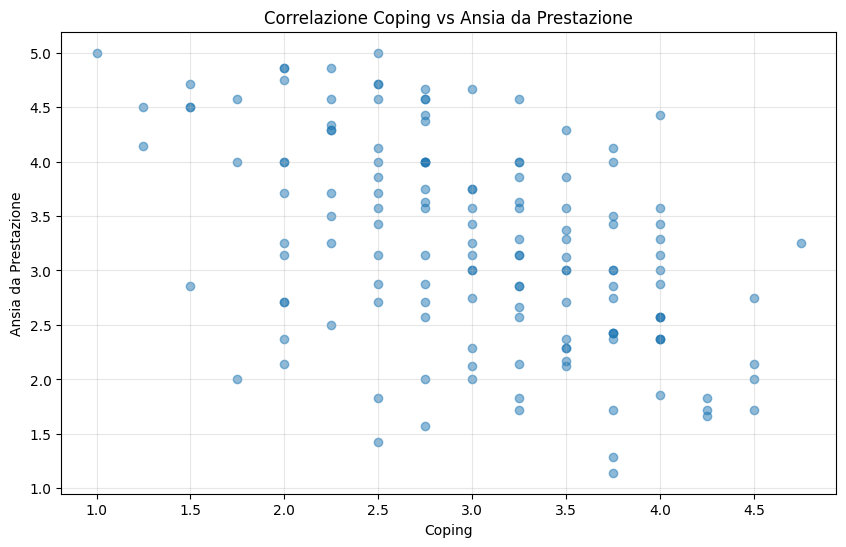

In [15]:
plt.figure(figsize=(10, 6))
plt.scatter(df["coping"], df["ansia_prestazione"], alpha=0.5)
plt.xlabel('Coping')
plt.ylabel('Ansia da Prestazione')
plt.title(f'Correlazione Coping vs Ansia da Prestazione')
plt.grid(True, alpha=0.3)

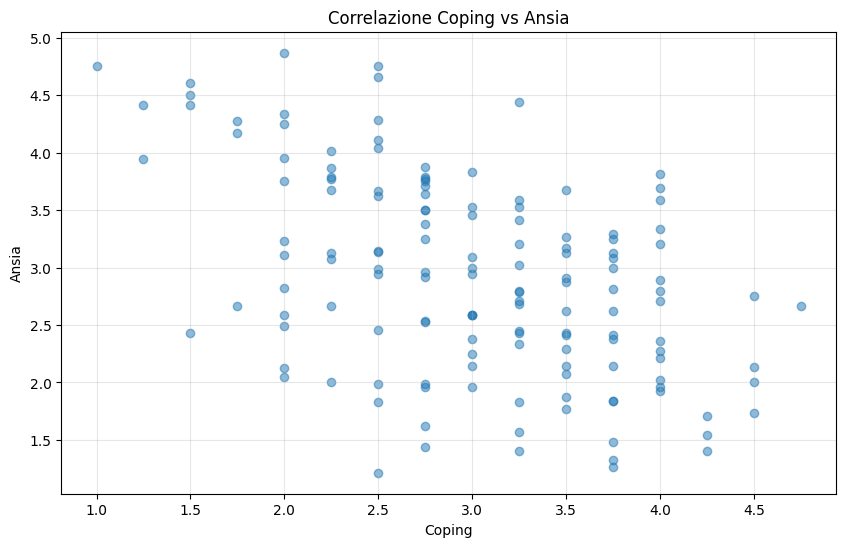

In [16]:
plt.figure(figsize=(10, 6))
plt.scatter(df["coping"], df["ansia"], alpha=0.5)
plt.xlabel('Coping')
plt.ylabel('Ansia')
plt.title(f'Correlazione Coping vs Ansia')
plt.grid(True, alpha=0.3)

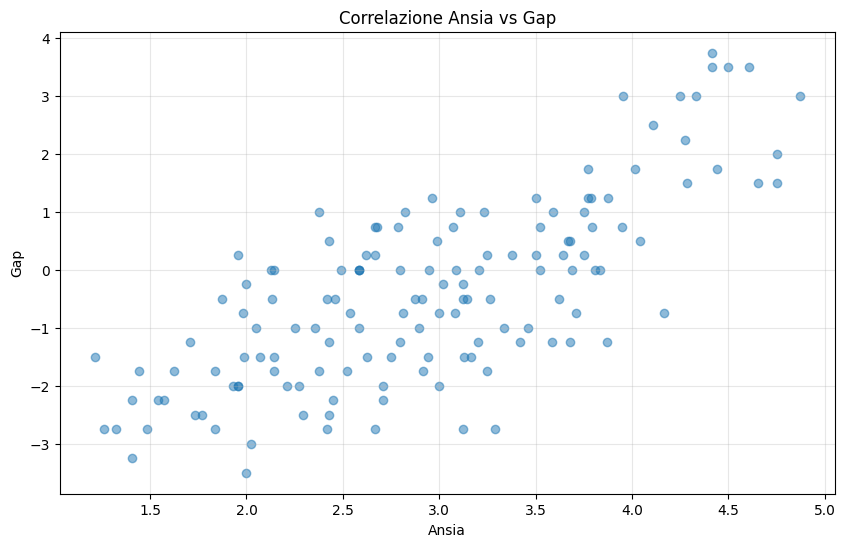

In [17]:
plt.figure(figsize=(10, 6))
plt.scatter(df["ansia"], df["gap"], alpha=0.5)
plt.xlabel('Ansia')
plt.ylabel('Gap')
plt.title(f'Correlazione Ansia vs Gap')
plt.grid(True, alpha=0.3)

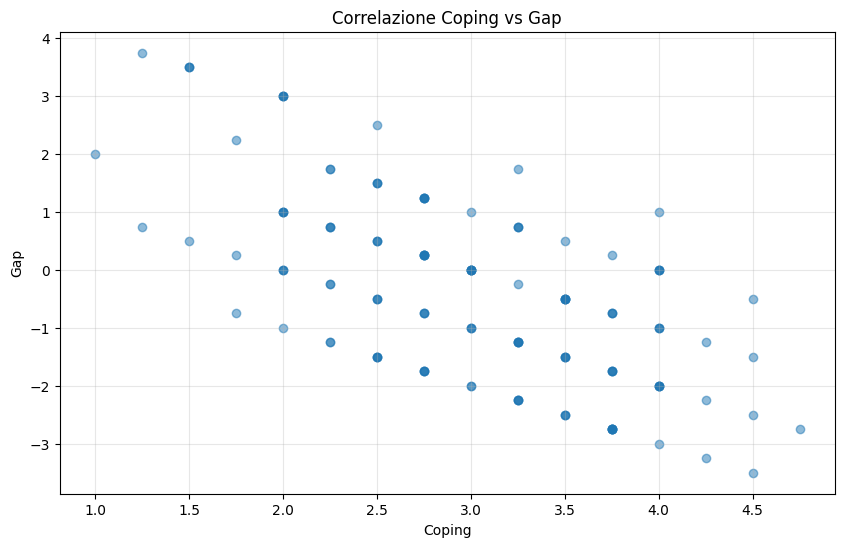

In [18]:
plt.figure(figsize=(10, 6))
plt.scatter(df["coping"], df["gap"], alpha=0.5)
plt.xlabel('Coping')
plt.ylabel('Gap')
plt.title(f'Correlazione Coping vs Gap')
plt.grid(True, alpha=0.3)

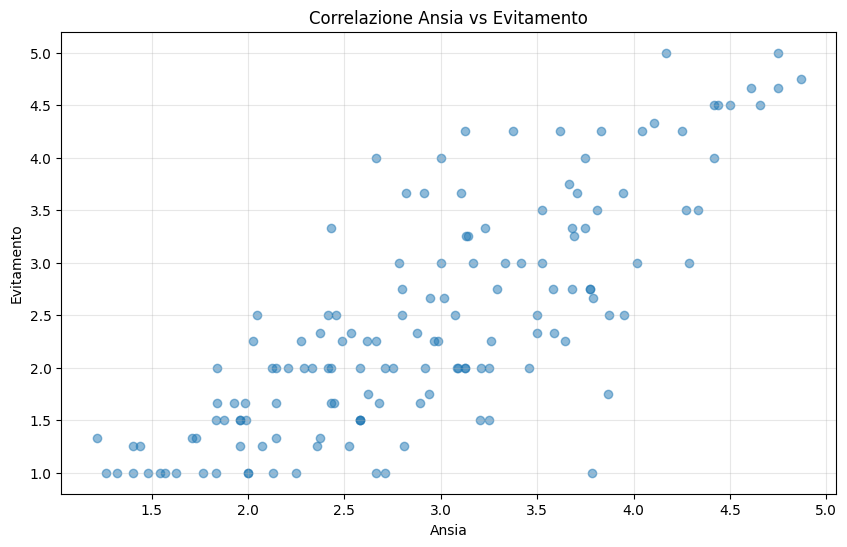

In [19]:
plt.figure(figsize=(10, 6))
plt.scatter(df["ansia"], df["evitamento"], alpha=0.5)
plt.xlabel('Ansia')
plt.ylabel('Evitamento')
plt.title(f'Correlazione Ansia vs Evitamento')
plt.grid(True, alpha=0.3)

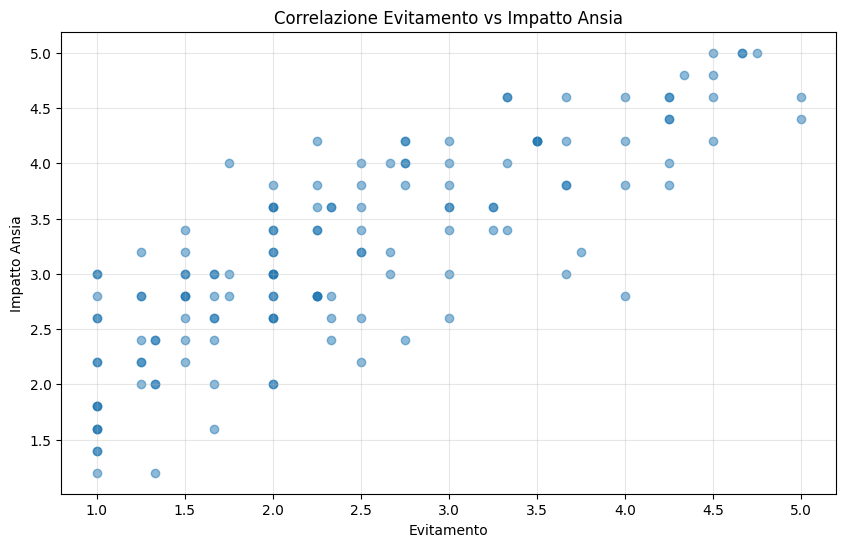

In [20]:
plt.figure(figsize=(10, 6))
plt.scatter(df["evitamento"], df["impatto_ansia"], alpha=0.5)
plt.xlabel('Evitamento')
plt.ylabel('Impatto Ansia')
plt.title(f'Correlazione Evitamento vs Impatto Ansia')
plt.grid(True, alpha=0.3)

# Correlazioni avanzate

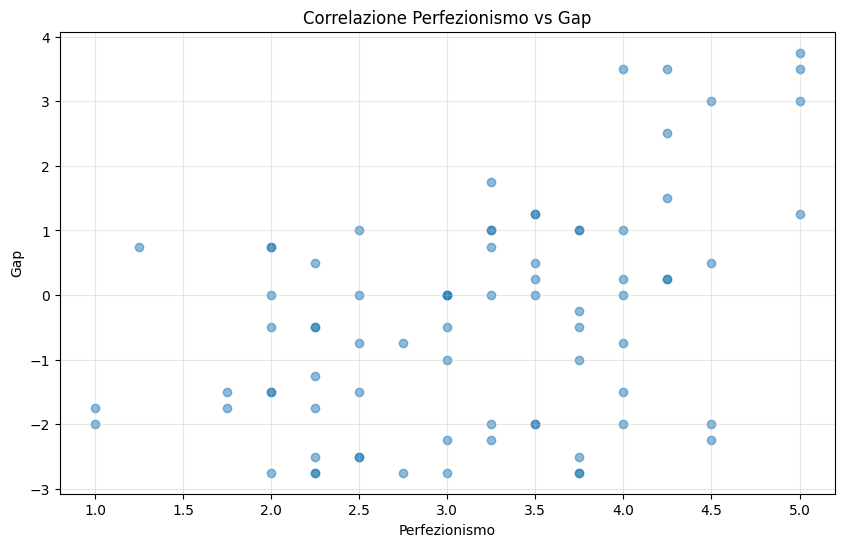

In [21]:
plt.figure(figsize=(10, 6))
plt.scatter(df["perfezionismo"], df["gap"], alpha=0.5)
plt.xlabel('Perfezionismo')
plt.ylabel('Gap')
plt.title(f'Correlazione Perfezionismo vs Gap')
plt.grid(True, alpha=0.3)

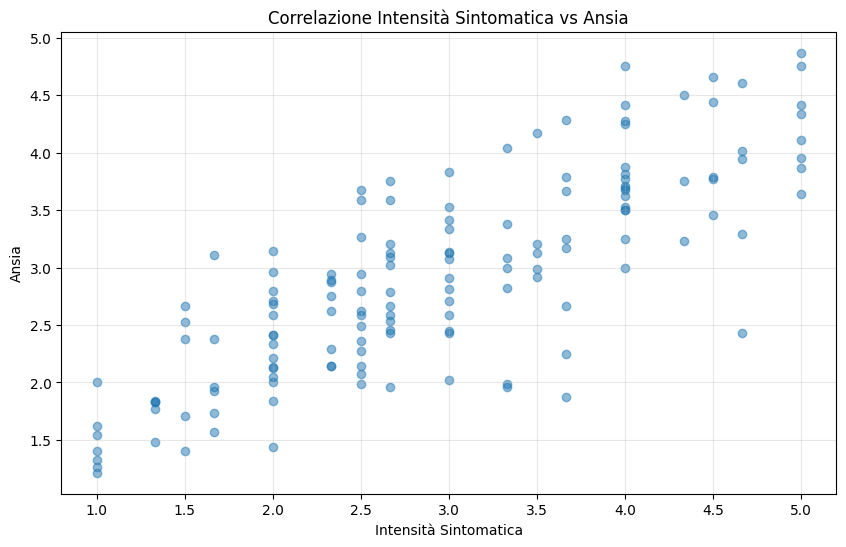

In [22]:
plt.figure(figsize=(10, 6))
plt.scatter(df["intensita_sintomatica"], df["ansia"], alpha=0.5)
plt.xlabel('Intensità Sintomatica')
plt.ylabel('Ansia')
plt.title(f'Correlazione Intensità Sintomatica vs Ansia')
plt.grid(True, alpha=0.3)

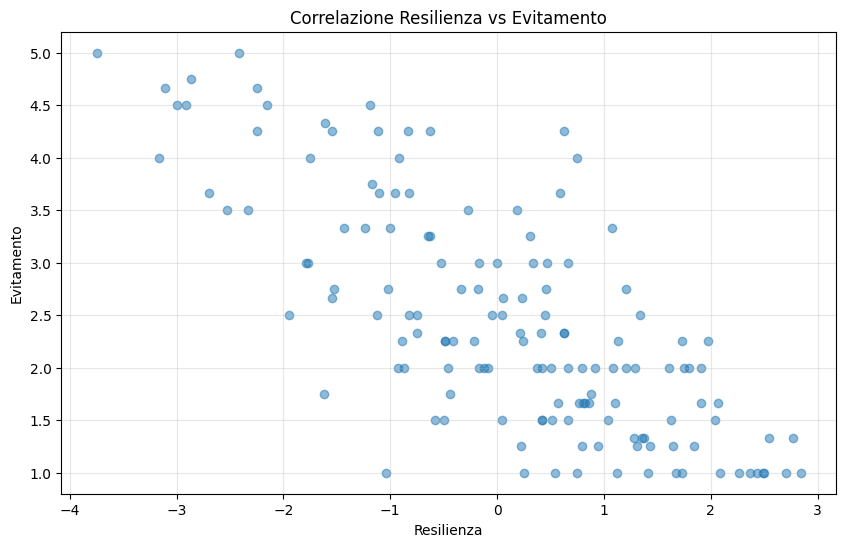

In [23]:
plt.figure(figsize=(10, 6))
plt.scatter(df["resilienza"], df["evitamento"], alpha=0.5)
plt.xlabel('Resilienza')
plt.ylabel('Evitamento')
plt.title(f'Correlazione Resilienza vs Evitamento')
plt.grid(True, alpha=0.3)

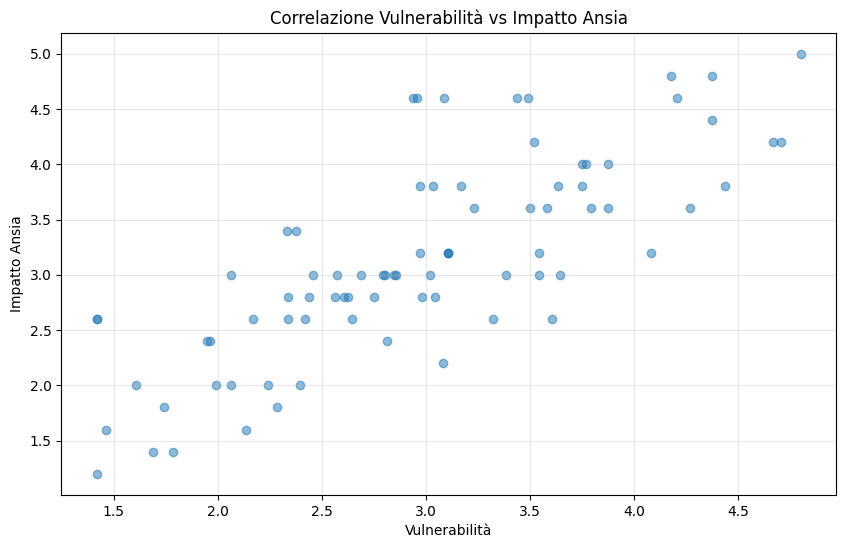

In [24]:
plt.figure(figsize=(10, 6))
plt.scatter(df["vulnerabilita"], df["impatto_ansia"], alpha=0.5)
plt.xlabel('Vulnerabilità')
plt.ylabel('Impatto Ansia')
plt.title(f'Correlazione Vulnerabilità vs Impatto Ansia')
plt.grid(True, alpha=0.3)

# Regressioni

In [25]:
#import librerie
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [ ]:
# Funzione per salvare i grafici
def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = os.path.join("../images", fig_id + "." + fig_extension)
    os.makedirs("../images", exist_ok=True)
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

### 1) Regressione: Resilienza vs Evitamento

In [27]:
# suddivisione tra X e y
X_1 = df[['resilienza']].values
y_1 = df['evitamento'].values

In [28]:
# suddivisione tra train e test
X_train_1, X_test_1, y_train_1, y_test_1 = train_test_split(X_1, y_1, test_size=0.2, random_state=42)

In [29]:
# istanza del modello
lin_reg = LinearRegression()
lin_reg.fit(X_train_1, y_train_1)

# Predizione
y_pred_1 = lin_reg.predict(X_test_1)

In [30]:
#valutazione
mse_1 = mean_squared_error(y_test_1, y_pred_1)
r2_1 = r2_score(y_test_1, y_pred_1)
print("Mean Squared Error:", mse_1)
print("R-squared:", r2_1)

Mean Squared Error: 0.4522028215743364
R-squared: 0.6557785302780845


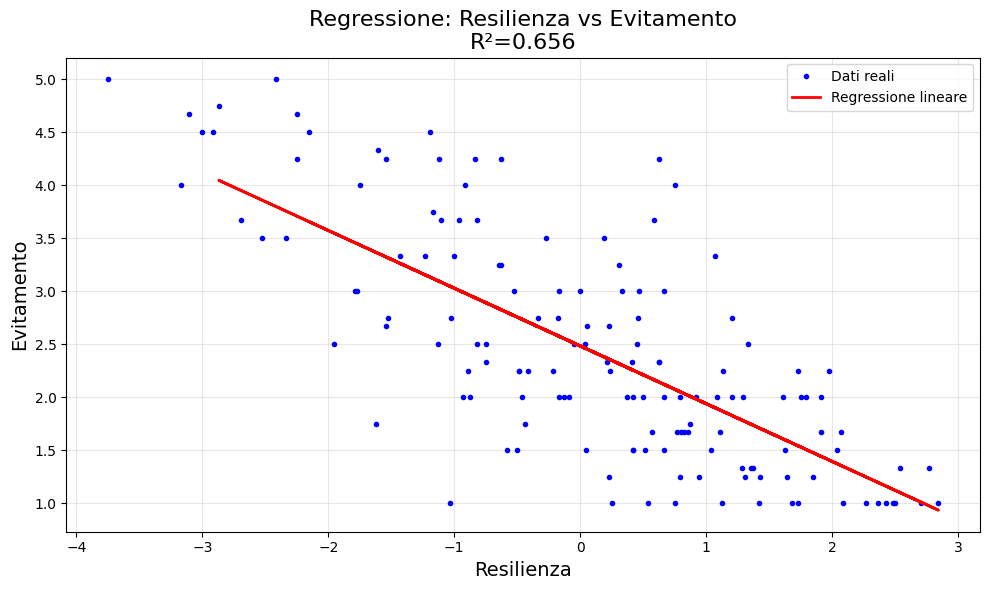

Coefficiente: -0.5445
Intercetta: 2.4833


In [31]:
# Grafico
plt.figure(figsize=(10, 6))
plt.plot(X_1, y_1, "b.", label='Dati reali')
plt.plot(X_test_1[:,0], y_pred_1, "r-", linewidth=2, label='Regressione lineare')
plt.xlabel("Resilienza", fontsize=14)
plt.ylabel("Evitamento", fontsize=14)
plt.title(f'Regressione: Resilienza vs Evitamento\nR²={r2_1:.3f}', fontsize=16)
plt.legend()
plt.grid(True, alpha=0.3)
save_fig("regressione_resilienza_evitamento")
plt.show()

print(f"Coefficiente: {lin_reg.coef_[0]:.4f}")
print(f"Intercetta: {lin_reg.intercept_:.4f}")

### 2) Regressione: Ansia vs Evitamento

In [32]:
X_2 = df[['ansia']].values
y_2 = df['evitamento'].values

In [33]:
X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(X_2, y_2, test_size=0.2, random_state=42)

In [34]:
# Modello
lin_reg2 = LinearRegression()
lin_reg2.fit(X_train_2, y_train_2)
y_pred_2 = lin_reg2.predict(X_test_2)

In [35]:
mse_2 = mean_squared_error(y_test_2, y_pred_2)
r2_2 = r2_score(y_test_2, y_pred_2)
print("Mean Squared Error:", mse_2)
print("R-squared:", r2_2)

Mean Squared Error: 0.3679437702256811
R-squared: 0.7199173925515049


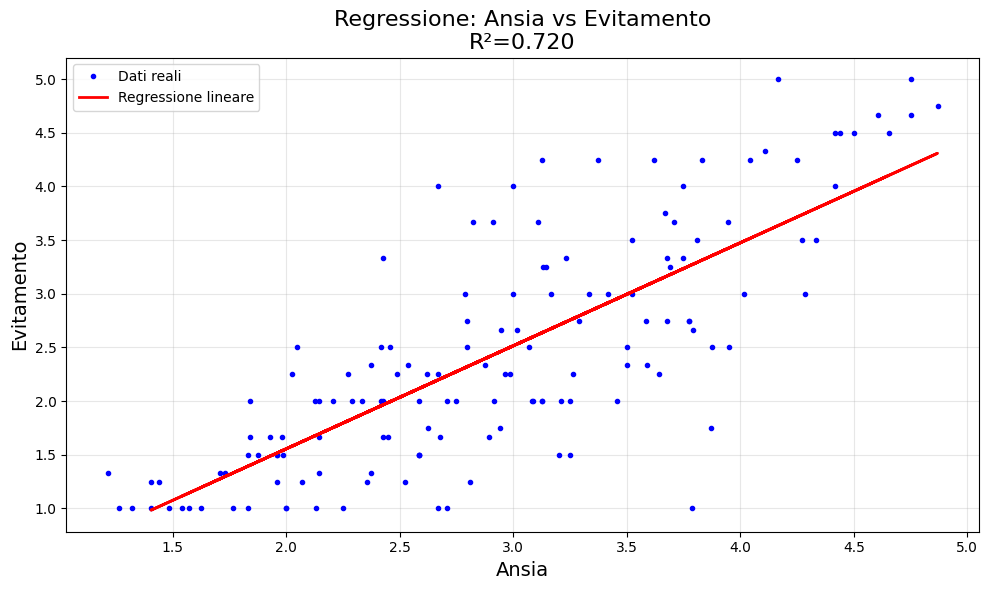

Coefficiente: 0.9599
Intercetta: -0.3648


In [36]:
# Grafico
plt.figure(figsize=(10, 6))
plt.plot(X_2, y_2, "b.", label='Dati reali')
plt.plot(X_test_2[:,0], y_pred_2, "r-", linewidth=2, label='Regressione lineare')
plt.xlabel("Ansia", fontsize=14)
plt.ylabel("Evitamento", fontsize=14)
plt.title(f'Regressione: Ansia vs Evitamento\nR²={r2_2:.3f}', fontsize=16)
plt.legend()
plt.grid(True, alpha=0.3)
save_fig("regressione_ansia_evitamento")
plt.show()

print(f"Coefficiente: {lin_reg2.coef_[0]:.4f}")
print(f"Intercetta: {lin_reg2.intercept_:.4f}")

### 3) Regressione: Ansia vs Coping

In [37]:
X_3 = df[['ansia']].values
y_3 = df['coping'].values

In [38]:
X_train_3, X_test_3, y_train_3, y_test_3 = train_test_split(X_3, y_3, test_size=0.2, random_state=42)

In [39]:
# Modello
lin_reg3 = LinearRegression()
lin_reg3.fit(X_train_3, y_train_3)
y_pred_3 = lin_reg3.predict(X_test_3)

In [40]:
mse_3 = mean_squared_error(y_test_3, y_pred_3)
r2_3 = r2_score(y_test_3, y_pred_3)
print("Mean Squared Error:", mse_3)
print("R-squared:", r2_3)

Mean Squared Error: 0.3978641292011239
R-squared: 0.23671803214566256


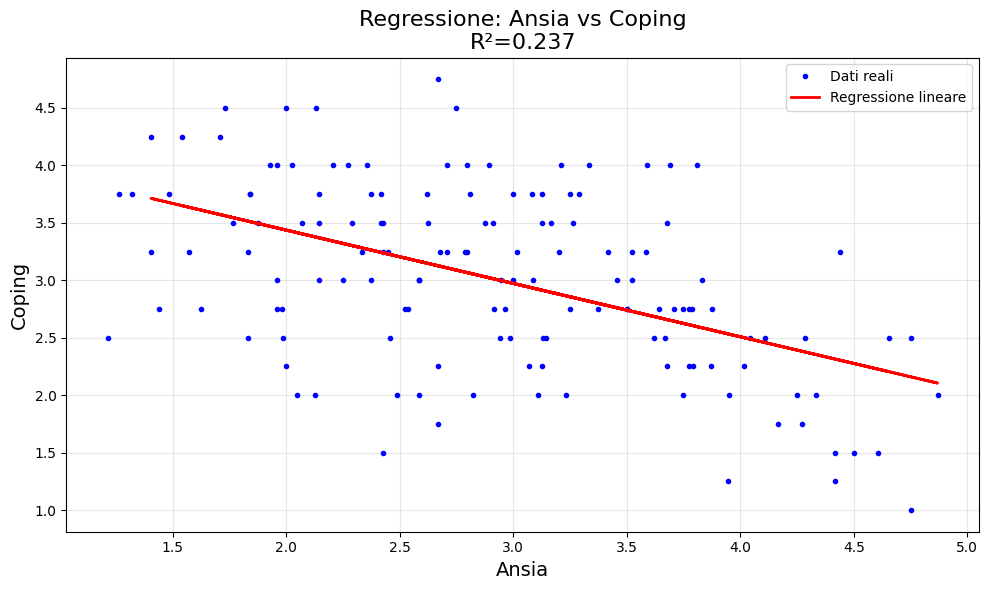

Coefficiente: -0.4640
Intercetta: 4.3644


In [41]:
# Grafico
plt.figure(figsize=(10, 6))
plt.plot(X_3, y_3, "b.", label='Dati reali')
plt.plot(X_test_3[:,0], y_pred_3, "r-", linewidth=2, label='Regressione lineare')
plt.xlabel("Ansia", fontsize=14)
plt.ylabel("Coping", fontsize=14)
plt.title(f'Regressione: Ansia vs Coping\nR²={r2_3:.3f}', fontsize=16)
plt.legend()
plt.grid(True, alpha=0.3)
save_fig("regressione_ansia_coping")
plt.show()

print(f"Coefficiente: {lin_reg3.coef_[0]:.4f}")
print(f"Intercetta: {lin_reg3.intercept_:.4f}")

In [42]:
from sklearn.preprocessing import PolynomialFeatures
poly_features = PolynomialFeatures(degree=2, include_bias=False)

# trasformo X_test
X_poly_3 = poly_features.fit_transform(X_3)

In [43]:
lin_reg3_2 = LinearRegression()

lin_reg3_2.fit(X_poly_3, y_3)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [44]:
y_pred_3_2 = lin_reg3_2.predict(X_poly_3)

In [45]:
mse_3_2 = mean_squared_error(y_3, y_pred_3_2)
r2_3_2 = r2_score(y_3, y_pred_3_2)
print("Mean Squared Error:", mse_3_2)
print("R-squared:", r2_3_2)

Mean Squared Error: 0.4465440231047396
R-squared: 0.28086503502367255


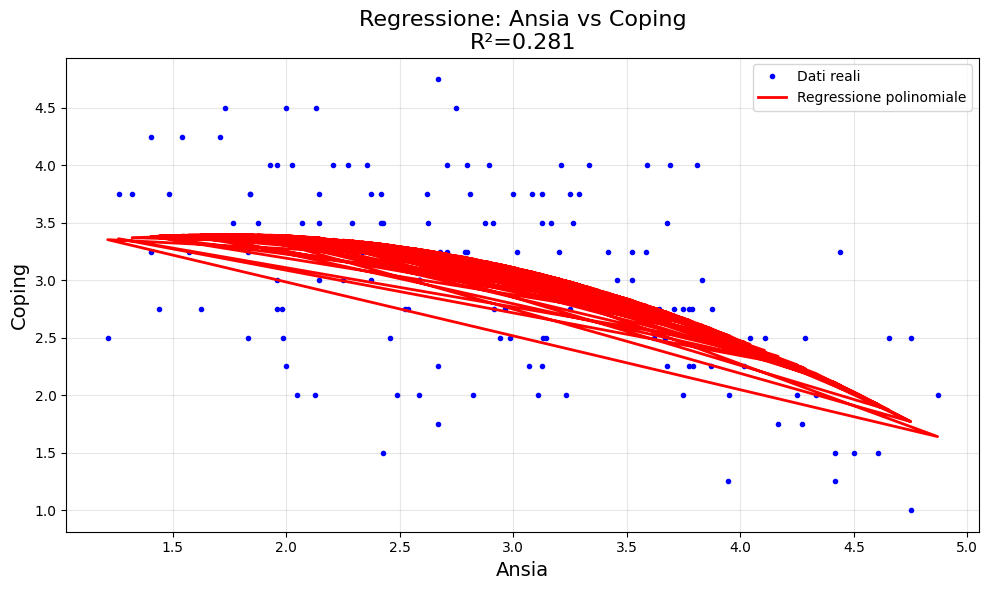

In [46]:
# Grafico
plt.figure(figsize=(10, 6))
plt.plot(X_3, y_3, "b.", label='Dati reali')
plt.plot(X_3, y_pred_3_2, "r-", linewidth=2, label='Regressione polinomiale')
plt.xlabel("Ansia", fontsize=14)
plt.ylabel("Coping", fontsize=14)
plt.title(f'Regressione: Ansia vs Coping\nR²={r2_3_2:.3f}', fontsize=16)
plt.legend()
plt.grid(True, alpha=0.3)
save_fig("regressione_ansia_coping")
plt.show()

In [47]:
# cross-validation


### 4) Regressione: Ansia vs Gap

In [52]:
# Creo copia del dataset
df_reg4 = df.copy()

# Sostituisco i NaN nella colonna target
df_reg4['gap'] = df_reg4['gap'].dropna()

X_4 = df_reg4['ansia'].values
y_4 = df_reg4['gap'].values

In [53]:
X_train_4, X_test_4, y_train_4, y_test_4 = train_test_split(X_4, y_4, test_size=0.2, random_state=42)

In [54]:
X_train_4.shape, y_train_4.shape

((115,), (115,))

In [55]:
# Modello
lin_reg4 = LinearRegression()
lin_reg4.fit(X_train_4, y_train_4)
y_pred_4 = lin_reg4.predict(X_test_4)

ValueError: Expected 2D array, got 1D array instead:
array=[2.91666667 4.41666667 3.875      2.25       1.48214286 1.83333333
 1.92857143 2.625      4.10714286 2.13095238 2.52380952 2.66666667
 3.         4.41666667 2.66666667 3.58928571 2.33333333 3.75
 3.52380952 3.         4.60714286 4.75       2.45833333 4.27380952
 2.91071429 2.98809524 2.42857143 3.70833333 2.29166667 2.04761905
 2.89285714 2.79761905 2.53571429 1.4047619  3.25       1.83333333
 4.33333333 3.29166667 3.5        2.375      2.42857143 4.25
 2.41666667 1.73214286 2.02380952 2.42857143 3.125      2.70833333
 3.67857143 3.41666667 3.10714286 3.78571429 1.26190476 3.52380952
 1.98809524 4.16666667 3.64285714 3.77380952 3.125      2.14285714
 2.70833333 3.94642857 1.95833333 2.75       3.95238095 2.41666667
 2.         1.57142857 2.125      3.23214286 3.08333333 3.79166667
 1.95833333 1.875      3.69047619 2.94642857 2.35714286 2.875
 2.44642857 3.33333333 2.         3.125      2.79761905 1.44047619
 2.27380952 2.14285714 3.26190476 3.25       1.21428571 2.80952381
 4.75       1.32142857 4.44047619 3.375      3.13095238 3.20238095
 2.375      2.58333333 1.83928571 3.58333333 2.61904762 3.66666667
 2.58333333 4.5        1.83928571 3.75       1.70833333 3.86904762
 2.67857143 4.28571429 3.16666667 3.20833333 3.01785714 2.07142857
 1.98214286].
Reshape your data either using array.reshape(-1, 1) if your data has a single feature or array.reshape(1, -1) if it contains a single sample.

In [ ]:
#valutazione
mse_4 = mean_squared_error(y_test_4, y_pred_4)
r2_4 = r2_score(y_test_4, y_pred_4)
print("Mean Squared Error:", mse_4)
print("R-squared:", r2_4)

In [ ]:
# Grafico
plt.figure(figsize=(10, 6))
plt.plot(X_4, y_4, "b.", label='Dati reali')
plt.plot(X_test_4[:,0], y_pred_4, "r-", linewidth=2, label='Regressione lineare')
plt.xlabel("Ansia", fontsize=14)
plt.ylabel("Gap", fontsize=14)
plt.title(f'Regressione: Ansia vs Gap\nR²={r2_4:.3f}', fontsize=16)
plt.legend()
plt.grid(True, alpha=0.3)
save_fig("regressione_ansia_gap")
plt.show()

print(f"Coefficiente: {lin_reg4.coef_[0]:.4f}")
print(f"Intercetta: {lin_reg4.intercept_:.4f}")